In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

os.listdir('/kaggle/input')

['datasets']

In [4]:
os.listdir('/kaggle/input/datasets')

['msambare']

In [5]:
import os
os.listdir('/kaggle/input/datasets/msambare')

['fer2013']

In [6]:
import os
os.listdir('/kaggle/input/datasets/msambare/fer2013')

['test', 'train']

In [7]:
import os

print(os.listdir('/kaggle/input/datasets/msambare/fer2013/train'))

['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']


In [8]:
import shutil
import os

source = '/kaggle/input/datasets/msambare/fer2013/train/disgust'
destination = '/kaggle/working/fer2013/train/angry'

os.makedirs(destination, exist_ok=True)

for file in os.listdir(source):
    shutil.copy(os.path.join(source, file), destination)

In [11]:
source = '/kaggle/input/datasets/msambare/fer2013/test/disgust'
destination = '/kaggle/working/fer2013/test/angry'

os.makedirs(destination, exist_ok=True)

for file in os.listdir(source):
    shutil.copy(os.path.join(source, file), destination)

In [12]:
import shutil

base_input = '/kaggle/input/datasets/msambare/fer2013'
base_output = '/kaggle/working/fer2013'

for split in ['train', 'test']:
    for emotion in os.listdir(f"{base_input}/{split}"):
        
        # skip disgust
        if emotion == 'disgust':
            continue
        
        src = f"{base_input}/{split}/{emotion}"
        dst = f"{base_output}/{split}/{emotion}"
        
        shutil.copytree(src, dst, dirs_exist_ok=True)

In [13]:
print(os.listdir('/kaggle/working/fer2013/train'))

['happy', 'angry', 'neutral', 'fear', 'sad', 'surprise']


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import BatchNormalization

2026-03-24 19:34:18.382888: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774380858.822654      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774380858.953247      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774380860.138135      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774380860.138168      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774380860.138171      55 computation_placer.cc:177] computation placer alr

In [17]:
train_dir = "/kaggle/working/fer2013/train"
test_dir = "/kaggle/working/fer2013/test"

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    batch_size=64,
    color_mode="grayscale",
    class_mode="categorical"
)

Found 28709 images belonging to 6 classes.
Found 7178 images belonging to 6 classes.


In [19]:
print(train_data.class_indices)

{'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


In [20]:
model = Sequential()

model.add(Conv2D(64, (5,5), padding='same', activation='relu', input_shape=(48,48,1)))
model.add(Conv2D(64, (5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (5,5), padding='same', activation='relu'))
model.add(Conv2D(128, (5,5), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dropout(0.2))

model.add(Dense(train_data.num_classes))
model.add(Activation('softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774380944.254563      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774380944.260594      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [22]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    shuffle=True
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774380955.590978     145 service.cc:152] XLA service 0x7a2248001fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774380955.591025     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774380955.591030     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774380956.385016     145 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/449 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.1484 - loss: 2.4969   

I0000 00:00:1774380965.614978     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


449/449 ━━━━━━━━━━━━━━━━━━━━ 44s 69ms/step - accuracy: 0.2590 - loss: 1.8299 - val_accuracy: 0.2849 - val_loss: 1.7653
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.3999 - loss: 1.5161 - val_accuracy: 0.2427 - val_loss: 2.0835
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.4702 - loss: 1.3483 - val_accuracy: 0.5226 - val_loss: 1.2310
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5199 - loss: 1.2358 - val_accuracy: 0.5610 - val_loss: 1.1570
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5549 - loss: 1.1534 - val_accuracy: 0.5665 - val_loss: 1.1137
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.5715 - loss: 1.1089 - val_accuracy: 0.5763 - val_loss: 1.1107
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.5874 - loss: 1.0709 - val_accuracy: 0.5669 - val_loss: 1.1356
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.6041 - loss: 1.0460 - val_accurac

In [24]:
model.save("emotion_model_final.h5")

print("Training completed successfully!")

Training completed successfully!


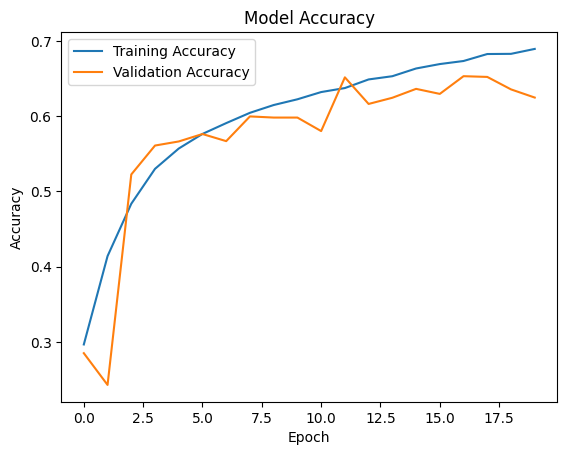

In [33]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

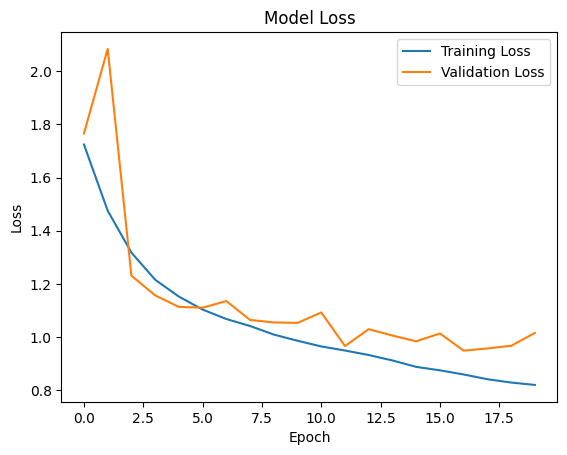

In [34]:
# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [25]:
import numpy as np

sample = next(test_data)[0][0]
sample = sample.reshape(1,48,48,1)

pred = model.predict(sample)
emotion_label = np.argmax(pred)

print("Predicted class index:", emotion_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted class index: 1


In [30]:
emotion_dict = {
    0: "angry",
    1: "angry",   # disgust merged
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

(np.float64(-0.5), np.float64(47.5), np.float64(47.5), np.float64(-0.5))

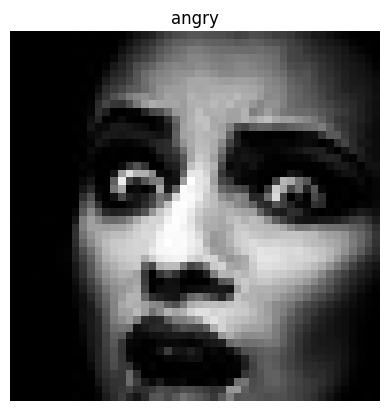

In [31]:
import matplotlib.pyplot as plt

plt.imshow(sample.reshape(48,48), cmap='gray')
plt.title(emotion_dict[emotion_label])
plt.axis('off')

In [37]:
# Milestone 3 - Music Dataset
import os

os.listdir('/kaggle/input')


['datasets']

In [38]:

os.listdir('/kaggle/input/datasets')


['notshrirang', 'msambare']

In [39]:
os.listdir('/kaggle/input/datasets/msambare')

['fer2013']

In [40]:
import os
os.listdir('/kaggle/input/datasets/notshrirang')

['spotify-million-song-dataset']

In [41]:
import os

os.listdir('/kaggle/input/datasets/notshrirang/spotify-million-song-dataset')

['spotify_millsongdata.csv']

In [42]:
import pandas as pd

music = pd.read_csv('/kaggle/input/datasets/notshrirang/spotify-million-song-dataset/spotify_millsongdata.csv')
music.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [43]:
print(music.columns)

Index(['artist', 'song', 'link', 'text'], dtype='object')


In [48]:
music = music.dropna()
music = music.sample(5000)  # reduce size for faster processing

In [49]:
def detect_mood(text):
    text = text.lower()
    
    if "love" in text or "happy" in text or "joy" in text:
        return "happy"
    elif "sad" in text or "cry" in text or "tears" in text:
        return "sad"
    elif "angry" in text or "hate" in text or "rage" in text:
        return "angry"
    elif "fear" in text or "scared" in text:
        return "fear"
    else:
        return "neutral"

In [51]:
music['mood'] = music['text'].apply(detect_mood)

In [52]:
music['mood'].value_counts()

mood
happy      2517
neutral    1824
sad         423
angry       153
fear         83
Name: count, dtype: int64

In [53]:
emotion_map = {
    0: "angry",
    1: "angry",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "happy",     # surprise → happy
    6: "neutral"
}

In [59]:
def recommend_music(emotion):
    mood = emotion_map.get(emotion, "neutral")
    
    songs = music[music['mood'] == mood]
    
    if len(songs) == 0:
        return music.sample(5)
    
    return songs[['artist', 'song']].sample(5)

In [56]:
import numpy as np

sample = next(test_data)[0][0].reshape(1,48,48,1)

pred = model.predict(sample)
emotion = np.argmax(pred)

print("Detected Emotion:", emotion_map[emotion])

recommend_music(emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Detected Emotion: sad


,artist,song
56664,Wishbone Ash,Comfort Zone
9879,Judas Priest,Exiled
53122,Tiffany,Should've Been Me
51621,Sia,Numb
49428,Queen Latifah,I Know Where I've Been


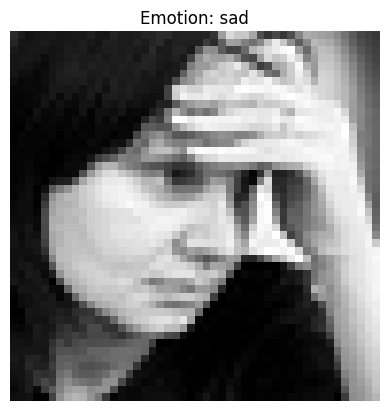


🎵 Recommended Songs:

Zucchero - You're Losing Me
Norah Jones - That's The Way The World Goes 'round
Dan Fogelberg - These Days
Alison Krauss - I Don't Believe You've Met My Baby
Queensryche - Suite Sister Mary


In [61]:
import matplotlib.pyplot as plt

# Show image
plt.imshow(sample.reshape(48,48), cmap='gray')
plt.title("Emotion: " + emotion_map[emotion])
plt.axis('off')
plt.show()

# Show songs
songs = recommend_music(emotion)

print("\n🎵 Recommended Songs:\n")

for i, row in songs.iterrows():
    print(f"{row['artist']} - {row['song']}")